# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** "Your Name"

---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)

### Yêu cầu
1. Tải bộ dữ liệu `California Housing` từ `sklearn.datasets`.
2. Chuyển đổi thành pandas DataFrame. Gán cột target là `MedHouseVal` (Giá nhà trung bình - đơn vị trăm nghìn USD).
3. In ra số dòng, số cột (shape) và thông tin kiểu dữ liệu (`.info()`).
4. Kiểm tra xem có giá trị thiếu (Missing values) nào trong bộ dữ liệu không.

### Gợi ý
- Hàm `fetch_california_housing(as_frame=True)` hỗ trợ trả về DataFrame trực tiếp qua thuộc tính `.frame`.
- Dùng `df.isnull().sum()` để đếm số lượng giá trị thiếu cho mỗi cột.

In [2]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan
# california = fetch_california_housing(as_frame=True)
# df = california.frame

# In shape, info và kiểm tra missing values
# ...
california_housing_dataset = fetch_california_housing(
    as_frame=True,
    data_home="."
)

#  Lấy toàn bộ dữ liệu, bao gồm features và target
housing_dataframe = california_housing_dataset.frame.copy()

# Xem 5 dòng đầu tiên
print("5 dòng đầu tiên của dữ liệu:")
display(housing_dataframe.head())

# In số dòng và số cột
number_of_rows, number_of_columns = housing_dataframe.shape

print(f"Số dòng: {number_of_rows}")
print(f"Số cột: {number_of_columns}")
print(f"Shape của dữ liệu: {housing_dataframe.shape}")

# Kiểm tra kiểu dữ liệu và số lượng giá trị không bị thiếu
print("\nThông tin tổng quan của dữ liệu:")
housing_dataframe.info()

# Kiểm tra giá trị thiếu của từng cột
missing_values_by_column = housing_dataframe.isnull().sum()

print("\nSố lượng giá trị thiếu theo từng cột:")
display(
    missing_values_by_column.to_frame(
        name="Số giá trị thiếu"
    )
)

print(
    f"Tổng số giá trị thiếu trong toàn bộ dữ liệu: "
    f"{missing_values_by_column.sum()}"
)

5 dòng đầu tiên của dữ liệu:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Số dòng: 20640
Số cột: 9
Shape của dữ liệu: (20640, 9)

Thông tin tổng quan của dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Số lượng giá trị thiếu theo từng cột:


,Số giá trị thiếu
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


Tổng số giá trị thiếu trong toàn bộ dữ liệu: 0


---
## Task 2 — Trực quan hóa Phân phối & Tương quan

### Yêu cầu
1. Vẽ biểu đồ Histogram (có đường cong KDE) cho biến mục tiêu `MedHouseVal`. Nhận xét xem phân phối có bị lệch (skew) không.
2. Vẽ ma trận tương quan (Heatmap) giữa tất cả các biến số trong dữ liệu.
3. **Trả lời:** Đặc trưng nào có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`)?

### Gợi ý
- Sử dụng `sns.histplot(data=df, x='MedHouseVal', kde=True)` để vẽ phân phối.
- Dùng `df.corr()` để tính ma trận tương quan và đưa vào `sns.heatmap(..., annot=True, cmap='coolwarm', fmt=".2f")` để vẽ biểu đồ nhiệt.

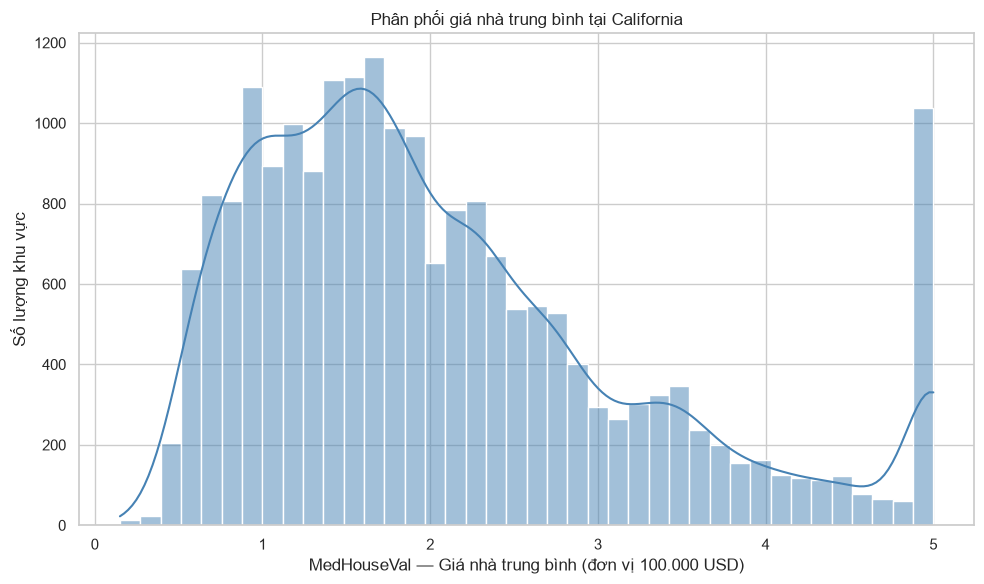

Độ lệch skewness của MedHouseVal: 0.9778


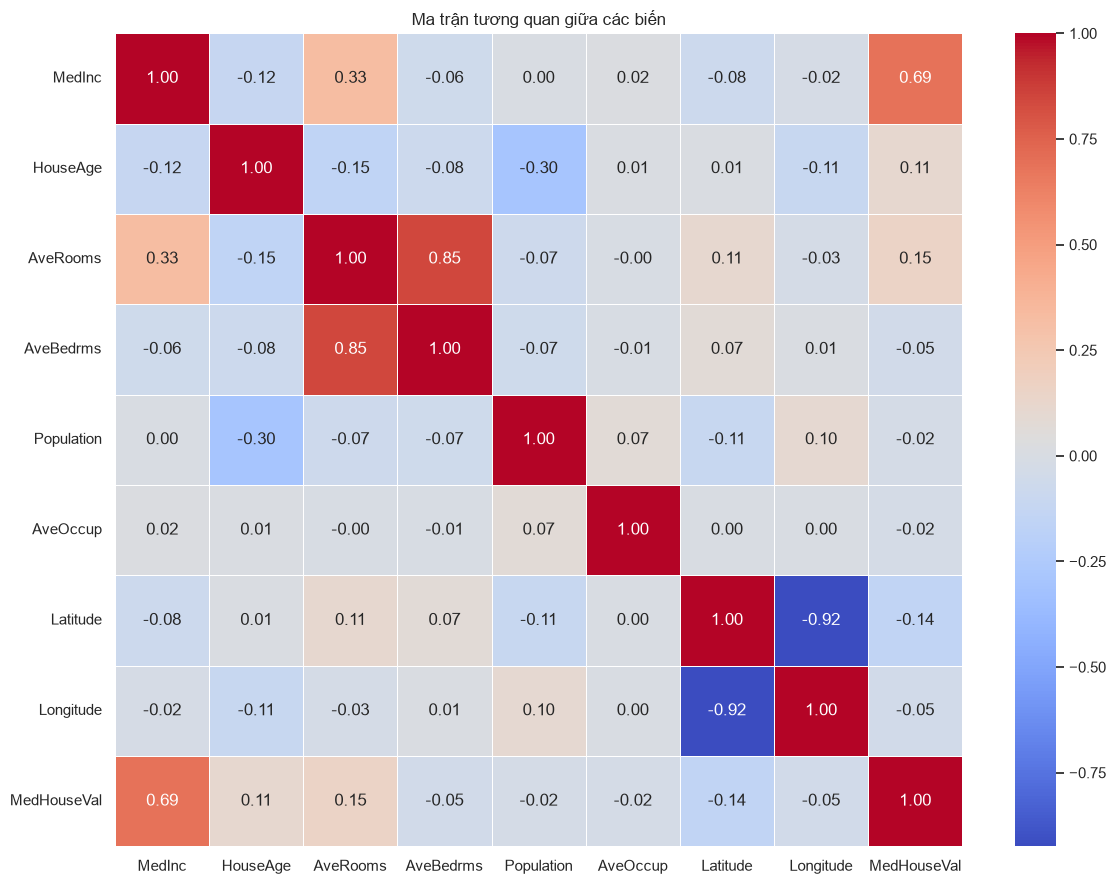

Tương quan giữa từng feature và MedHouseVal:


,Correlation
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


Feature có tương quan dương mạnh nhất với MedHouseVal là MedInc, với hệ số tương quan 0.6881.


In [3]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
# ...
plt.figure(figsize=(10, 6))

sns.histplot(
    data=housing_dataframe,
    x="MedHouseVal",
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Phân phối giá nhà trung bình tại California")
plt.xlabel(
    "MedHouseVal — Giá nhà trung bình "
    "(đơn vị 100.000 USD)"
)
plt.ylabel("Số lượng khu vực")
plt.tight_layout()
plt.show()


# Tính độ lệch của phân phối để hỗ trợ phần nhận xét
target_skewness = housing_dataframe["MedHouseVal"].skew()

print(
    f"Độ lệch skewness của MedHouseVal: "
    f"{target_skewness:.4f}"
)
# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
# plt.figure(figsize=(10, 8))
# ...
correlation_matrix = housing_dataframe.corr(
    numeric_only=True
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Ma trận tương quan giữa các biến")
plt.tight_layout()
plt.show()



# Lấy cột tương quan với MedHouseVal
correlation_with_target = correlation_matrix[
    "MedHouseVal"
]

# Bỏ tương quan của MedHouseVal với chính nó
correlation_with_target = correlation_with_target.drop(
    "MedHouseVal"
)

# Sắp xếp hệ số tương quan từ lớn xuống nhỏ
correlation_with_target = correlation_with_target.sort_values(
    ascending=False
)

print("Tương quan giữa từng feature và MedHouseVal:")

display(
    correlation_with_target.to_frame(
        name="Correlation"
    )
)

# Feature đầu tiên là feature có tương quan dương lớn nhất
strongest_positive_feature = correlation_with_target.index[0]

strongest_positive_correlation = (
    correlation_with_target.iloc[0]
)

print(
    f"Feature có tương quan dương mạnh nhất với "
    f"MedHouseVal là {strongest_positive_feature}, "
    f"với hệ số tương quan "
    f"{strongest_positive_correlation:.4f}."
)

**Trả lời 2:**

- Biến mục tiêu `MedHouseVal` có phân phối **lệch phải** vì phần lớn giá trị tập trung ở vùng giá thấp và trung bình, trong khi vẫn có một đuôi kéo dài về phía các giá trị lớn. Skewness xấp xỉ **0,98**, lớn hơn 0, nên kết luận phân phối lệch phải là phù hợp.
- Biểu đồ còn xuất hiện một cột cao tại giá trị khoảng `5.0`. Nguyên nhân là bộ dữ liệu đã giới hạn các giá nhà lớn nhất ở mức xấp xỉ 5, tương đương khoảng 500.000 USD.
- Feature có tương quan dương mạnh nhất với `MedHouseVal` là **`MedInc`** với hệ số tương quan khoảng **0,69**. Điều này cho thấy khu vực có thu nhập trung vị cao hơn thường có giá nhà cao hơn.

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)

Với các mô hình có sử dụng Regularization như Ridge và Lasso, việc **Scale dữ liệu** (đưa về cùng thang đo) là **BẮT BUỘC**. Nếu không scale, các đặc trưng có miền giá trị lớn (ví dụ như Population) sẽ lấn át các đặc trưng có miền giá trị nhỏ, làm sai lệch tác dụng của hệ số phạt L1/L2.

### Yêu cầu
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**.
3. Dùng `StandardScaler` để scale tập `X`. **Quan trọng:** Chỉ `.fit()` trên `X_train`, sau đó dùng tham số đã học đó để `.transform()` cho cả `X_train` và `X_test`.

### Gợi ý
- `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `scaler.fit_transform(X_train)` cho tập train và `scaler.transform(X_test)` cho tập test.

In [4]:
# TODO 3: Chia tập và Scale dữ liệu


# X_train, X_test, y_train, y_test = train_test_split(...)

# scaler = StandardScaler()
# X_train_scaled = ...
# X_test_scaled = ...
# Features là tất cả các cột, ngoại trừ MedHouseVal
feature_dataframe = housing_dataframe.drop(
    columns=["MedHouseVal"]
)

# Target là cột MedHouseVal
target_series = housing_dataframe["MedHouseVal"]

print(
    "Kích thước features ban đầu:",
    feature_dataframe.shape
)

print(
    "Kích thước target ban đầu:",
    target_series.shape
)


# =========================================================
# Bước 2: Chia dữ liệu thành tập train và tập test
# =========================================================

(
    training_features,
    testing_features,
    training_target,
    testing_target
) = train_test_split(
    feature_dataframe,
    target_series,
    test_size=0.20,
    random_state=42
)

print("\nSau khi chia dữ liệu:")

print(
    "Training features:",
    training_features.shape
)

print(
    "Testing features:",
    testing_features.shape
)

print(
    "Training target:",
    training_target.shape
)

print(
    "Testing target:",
    testing_target.shape
)


# =========================================================
# Bước 3: Chuẩn hóa dữ liệu bằng StandardScaler
# =========================================================

# Khởi tạo bộ chuẩn hóa
feature_scaler = StandardScaler()

# Chỉ fit scaler trên tập train để tránh Data Leakage
scaled_training_features_array = (
    feature_scaler.fit_transform(
        training_features
    )
)

# Tập test chỉ được transform
# Không được fit lại scaler trên tập test
scaled_testing_features_array = (
    feature_scaler.transform(
        testing_features
    )
)


# =========================================================
# Bước 4: Chuyển kết quả về DataFrame
# =========================================================

scaled_training_features = pd.DataFrame(
    scaled_training_features_array,
    columns=training_features.columns,
    index=training_features.index
)

scaled_testing_features = pd.DataFrame(
    scaled_testing_features_array,
    columns=testing_features.columns,
    index=testing_features.index
)

print(
    "\n5 dòng đầu của tập train "
    "sau khi chuẩn hóa:"
)

display(
    scaled_training_features.head()
)


print(
    "Giá trị trung bình của các feature "
    "trong tập train sau khi chuẩn hóa:"
)

display(
    scaled_training_features
    .mean()
    .round(4)
    .to_frame(name="Mean")
)


print(
    "Độ lệch chuẩn của các feature "
    "trong tập train sau khi chuẩn hóa:"
)

display(
    scaled_training_features
    .std(ddof=0)
    .round(4)
    .to_frame(name="Standard deviation")
)

Kích thước features ban đầu: (20640, 8)
Kích thước target ban đầu: (20640,)

Sau khi chia dữ liệu:
Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)

5 dòng đầu của tập train sau khi chuẩn hóa:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


Giá trị trung bình của các feature trong tập train sau khi chuẩn hóa:


,Mean
MedInc,-0.0
HouseAge,-0.0
AveRooms,0.0
AveBedrms,-0.0
Population,0.0
AveOccup,0.0
Latitude,0.0
Longitude,0.0


Độ lệch chuẩn của các feature trong tập train sau khi chuẩn hóa:


,Standard deviation
MedInc,1.0
HouseAge,1.0
AveRooms,1.0
AveBedrms,1.0
Population,1.0
AveOccup,1.0
Latitude,1.0
Longitude,1.0


---
## Task 4 — Huấn luyện Vanilla Linear Regression

### Yêu cầu
1. Khởi tạo và huấn luyện mô hình `LinearRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Tính và in ra 2 chỉ số đánh giá: **RMSE** (Root Mean Squared Error) và **R² Score**.

### Gợi ý
- RMSE có thể tính bằng `np.sqrt(mean_squared_error(y_true, y_pred))`.
- Hàm `r2_score(y_true, y_pred)` sẽ trả về chỉ số R² (hệ số xác định).

In [5]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
# lr_model = LinearRegression()
# ...

# y_pred_lr = ...

# rmse_lr = ...
# r2_lr = ...
# print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")
def evaluate_regression_model(
    model,
    test_features,
    actual_target
):
      # Dự đoán target từ dữ liệu test
    predicted_target = model.predict(
        test_features
    )

    # Tính Mean Squared Error
    mean_squared_error_value = mean_squared_error(
        actual_target,
        predicted_target
    )

    # Lấy căn bậc hai của MSE để có RMSE
    root_mean_squared_error = np.sqrt(
        mean_squared_error_value
    )

    # Tính hệ số xác định R²
    coefficient_of_determination = r2_score(
        actual_target,
        predicted_target
    )

    return (
        predicted_target,
        root_mean_squared_error,
        coefficient_of_determination
    )

linear_regression_model = LinearRegression()
linear_regression_model.fit(
    scaled_training_features,
    training_target
)
(
    linear_regression_predictions,
    linear_regression_rmse,
    linear_regression_r2
) = evaluate_regression_model(
    linear_regression_model,
    scaled_testing_features,
    testing_target
)


print("Kết quả Linear Regression")

print(
    f"RMSE: {linear_regression_rmse:.4f}"
)

print(
    f"R² Score: {linear_regression_r2:.4f}"
)


Kết quả Linear Regression
RMSE: 0.7456
R² Score: 0.5758


---
## Task 5 — Huấn luyện Ridge và Lasso Regression

### Yêu cầu
1. Huấn luyện mô hình **Ridge** với tham số siêu việt `alpha=10.0`.
2. Huấn luyện mô hình **Lasso** với tham số siêu việt `alpha=0.1`.
3. Tính RMSE và R² cho cả 2 mô hình trên tập Test và in kết quả để so sánh.

### Gợi ý
- Khởi tạo mô hình: `Ridge(alpha=10.0)` và `Lasso(alpha=0.1)`.
- Bạn có thể viết một hàm `evaluate_model(model, X_test, y_test)` nhỏ để tái sử dụng code tính RMSE và R² cho đỡ lặp lại.

In [6]:
# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
# ridge_model = Ridge(alpha=10.0)
# ...
# Khởi tạo Ridge Regression với alpha = 10
ridge_regression_model = Ridge(
    alpha=10.0
)

# Huấn luyện Ridge trên tập train đã chuẩn hóa
ridge_regression_model.fit(
    scaled_training_features,
    training_target
)

# Đánh giá Ridge trên tập test
(
    ridge_regression_predictions,
    ridge_regression_rmse,
    ridge_regression_r2
) = evaluate_regression_model(
    ridge_regression_model,
    scaled_testing_features,
    testing_target
)


# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
# lasso_model = Lasso(alpha=0.1)
# ...
lasso_regression_model = Lasso(
    alpha=0.1,
    max_iter=10000
)

# Huấn luyện Lasso trên tập train đã chuẩn hóa
lasso_regression_model.fit(
    scaled_training_features,
    training_target
)

# Đánh giá Lasso trên tập test
(
    lasso_regression_predictions,
    lasso_regression_rmse,
    lasso_regression_r2
) = evaluate_regression_model(
    lasso_regression_model,
    scaled_testing_features,
    testing_target
)
# soosanh

model_comparison_dataframe = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "RMSE": [
        linear_regression_rmse,
        ridge_regression_rmse,
        lasso_regression_rmse
    ],
    "R2 Score": [
        linear_regression_r2,
        ridge_regression_r2,
        lasso_regression_r2
    ]
})

print("Bảng so sánh kết quả:")

display(
    model_comparison_dataframe.round(4)
)


# Tìm mô hình có RMSE nhỏ nhất
best_model_row_index = (
    model_comparison_dataframe["RMSE"].idxmin()
)

best_model_by_rmse = (
    model_comparison_dataframe.loc[
        best_model_row_index,
        "Model"
    ]
)

print(
    f"Mô hình có RMSE nhỏ nhất "
    f"trong ba mô hình là: "
    f"{best_model_by_rmse}"
)

Bảng so sánh kết quả:


,Model,RMSE,R2 Score
0,Linear Regression,0.7456,0.5758
1,Ridge Regression,0.7453,0.5761
2,Lasso Regression,0.8244,0.4814


Mô hình có RMSE nhỏ nhất trong ba mô hình là: Ridge Regression


---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)

Đây là phần cốt lõi để thấy sự khác biệt về mặt toán học giữa L1 và L2 Regularization.

### Yêu cầu
1. Lấy mảng hệ số hồi quy (`.coef_`) từ cả 3 mô hình (Linear, Ridge, Lasso).
2. Tạo một DataFrame lưu trữ các hệ số này với Index là tên các features.
3. Vẽ biểu đồ Barplot so sánh các trọng số của 3 mô hình cạnh nhau cho từng feature.
4. **Trả lời:** Quan sát hệ số của Lasso, bạn thấy điều gì đặc biệt xảy ra với một số features? Tính chất này thường được ứng dụng để làm gì?

### Gợi ý
- `california.feature_names` trả về danh sách tên cột.
- Có thể gom thành Pandas DataFrame và gọi lệnh `df_coefs.plot(kind='bar', figsize=(12, 6))` để pandas tự động vẽ các thanh cạnh nhau.

Hệ số hồi quy của các mô hình:


,Linear Regression,Ridge Regression,Lasso Regression
Feature,,,
MedInc,0.8544,0.8538,0.7106
HouseAge,0.1225,0.1233,0.1065
AveRooms,-0.2944,-0.2924,-0.0000
AveBedrms,0.3393,0.3367,0.0000
Population,-0.0023,-0.0021,-0.0000
AveOccup,-0.0408,-0.0409,-0.0000
Latitude,-0.8969,-0.8894,-0.0115
Longitude,-0.8698,-0.8622,-0.0000


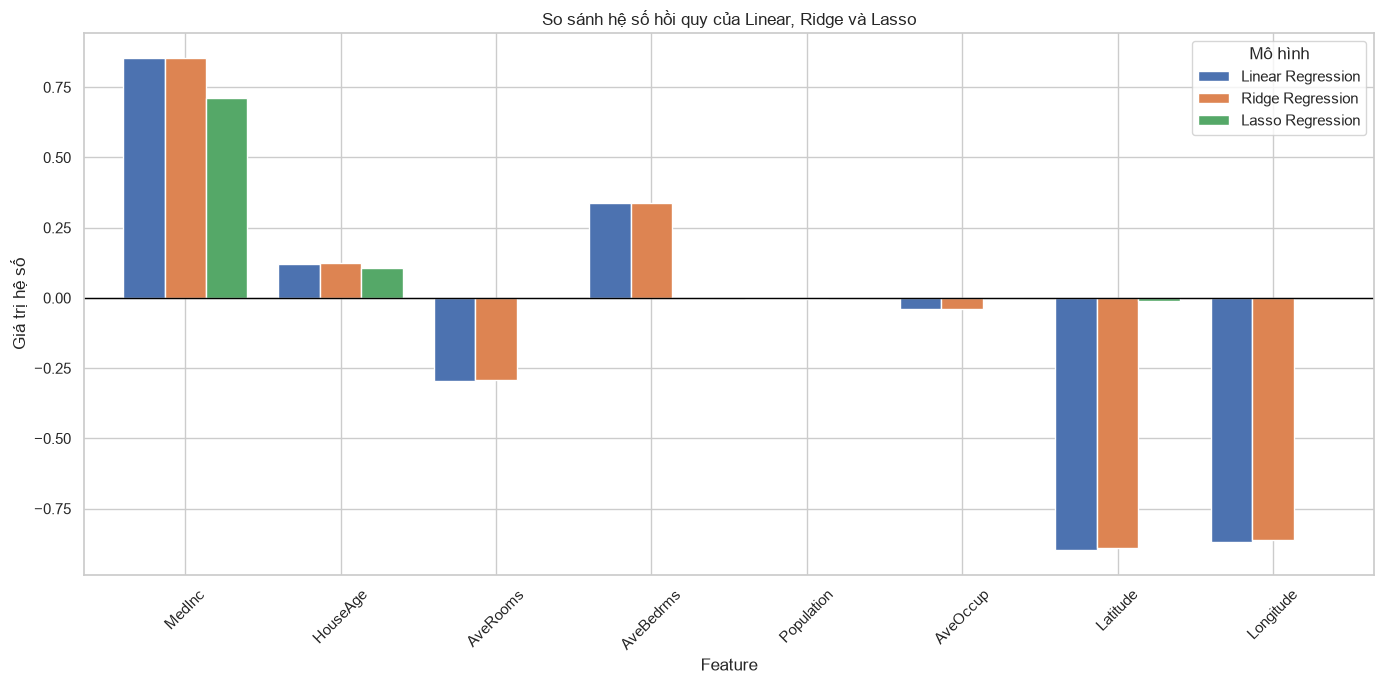

Các features có hệ số bằng 0 trong mô hình Lasso:
['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']
Số features bị loại bởi Lasso: 5/8


In [7]:
# TODO 6: Trực quan hóa Coefficients
# features = ...
# coef_df = pd.DataFrame({
#     'Linear': lr_model.coef_,
#     'Ridge': ridge_model.coef_,
#     'Lasso': lasso_model.coef_
# }, index=features)

# Vẽ biểu đồ so sánh
# coef_df.plot(...)
# plt.title("So sánh hệ số hồi quy của các mô hình")
# plt.ylabel("Giá trị Coefficient")
# plt.show()
feature_names = feature_dataframe.columns.tolist()
coefficient_dataframe = pd.DataFrame(
    {
        "Linear Regression":
            linear_regression_model.coef_,

        "Ridge Regression":
            ridge_regression_model.coef_,

        "Lasso Regression":
            lasso_regression_model.coef_
    },
    index=feature_names
)

# Đặt tên cho cột index
coefficient_dataframe.index.name = "Feature"

print("Hệ số hồi quy của các mô hình:")

display(
    coefficient_dataframe.round(4)
)

coefficient_dataframe.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

plt.title(
    "So sánh hệ số hồi quy của "
    "Linear, Ridge và Lasso"
)

plt.xlabel("Feature")
plt.ylabel("Giá trị hệ số")
plt.xticks(rotation=45)

# Vẽ đường ngang tại hệ số bằng 0
plt.axhline(
    y=0,
    linewidth=1,
    color="black"
)

plt.legend(title="Mô hình")
plt.tight_layout()
plt.show()

lasso_zero_coefficient_condition = np.isclose(
    coefficient_dataframe["Lasso Regression"],
    0.0
)

lasso_zero_coefficient_features = (
    coefficient_dataframe.index[
        lasso_zero_coefficient_condition
    ].tolist()
)

print(
    "Các features có hệ số bằng 0 "
    "trong mô hình Lasso:"
)

print(
    lasso_zero_coefficient_features
)

print(
    f"Số features bị loại bởi Lasso: "
    f"{len(lasso_zero_coefficient_features)}"
    f"/{len(feature_names)}"
)

**Trả lời 6:**
- Với `alpha = 0.1`, Lasso đã ép hệ số của nhiều features về **đúng bằng 0**. Trong kết quả này, các biến như `AveRooms`, `AveBedrms`, `Population`, `AveOccup` và `Longitude` có hệ số bằng 0 hoặc gần như bằng 0.
- Khi hệ số của một feature bằng 0, feature đó không còn đóng góp trực tiếp vào dự đoán của mô hình.
- Đây là tính chất đặc trưng của **L1 Regularization**. Lasso vừa giúp hạn chế mô hình quá khớp, vừa có thể thực hiện **Feature Selection** bằng cách tự động loại bớt những đặc trưng ít quan trọng.
- Ridge sử dụng L2 Regularization nên thường chỉ làm các hệ số nhỏ lại, chứ hiếm khi ép chúng về đúng bằng 0.

---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV

Ở Task 5, chúng ta chỉ chọn bừa `alpha=10.0` và `alpha=0.1`. Làm sao để biết `alpha` bao nhiêu là tốt nhất cho bộ dữ liệu này?

### Yêu cầu
Sử dụng `GridSearchCV` để chạy thử nghiệm nghiệm chéo (Cross-Validation) tìm giá trị `alpha` tối ưu cho Ridge Regression trong danh sách: `[0.1, 1.0, 10.0, 100.0]`.

### Gợi ý
- Import: `from sklearn.model_selection import GridSearchCV`.
- Cấu hình param grid: `param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}`.
- In ra `grid_search.best_params_` sau khi fit trên tập Train.

In [8]:
from sklearn.model_selection import GridSearchCV

In [9]:
# TODO Bonus: GridSearchCV cho Ridge
# param_grid = {...}
# grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
# grid_search.fit(X_train_scaled, y_train)
# print(f"Alpha tốt nhất cho Ridge: {grid_search.best_params_}")
ridge_alpha_grid = {
    "alpha": [
        0.1,
        1.0,
        10.0,
        100.0
    ]
}
# cv=5:
# Chia tập train thành 5 phần để thực hiện Cross-Validation

# scoring="neg_root_mean_squared_error":
# GridSearchCV luôn chọn score lớn nhất.
# Do RMSE càng nhỏ càng tốt, scikit-learn đổi RMSE thành số âm.

ridge_grid_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_alpha_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

ridge_grid_search.fit(
    scaled_training_features,
    training_target
)
best_ridge_alpha = (
    ridge_grid_search.best_params_["alpha"]
)

# best_score_ là RMSE âm nên cần đổi dấu
best_cross_validation_rmse = (
    -ridge_grid_search.best_score_
)

print(
    f"Alpha tốt nhất cho Ridge: "
    f"{best_ridge_alpha}"
)

print(
    f"RMSE trung bình tốt nhất trên "
    f"5-fold Cross-Validation: "
    f"{best_cross_validation_rmse:.4f}"
)

best_ridge_model = (
    ridge_grid_search.best_estimator_
)

(
    best_ridge_predictions,
    best_ridge_test_rmse,
    best_ridge_test_r2
) = evaluate_regression_model(
    best_ridge_model,
    scaled_testing_features,
    testing_target
)

print(
    "\nKết quả Ridge tốt nhất "
    "trên tập test:"
)

print(
    f"RMSE: {best_ridge_test_rmse:.4f}"
)

print(
    f"R² Score: {best_ridge_test_r2:.4f}"
)

grid_search_result_dataframe = pd.DataFrame(
    ridge_grid_search.cv_results_
)

# Chỉ lấy các cột cần quan tâm
grid_search_result_dataframe = (
    grid_search_result_dataframe[
        [
            "param_alpha",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].copy()
)

# Chuyển RMSE âm thành RMSE dương
grid_search_result_dataframe[
    "mean_test_rmse"
] = (
    -grid_search_result_dataframe[
        "mean_test_score"
    ]
)

# Sắp xếp lại các cột
grid_search_result_dataframe = (
    grid_search_result_dataframe[
        [
            "param_alpha",
            "mean_test_rmse",
            "std_test_score",
            "rank_test_score"
        ]
    ]
)

# Sắp xếp theo thứ hạng
grid_search_result_dataframe = (
    grid_search_result_dataframe.sort_values(
        "rank_test_score"
    )
)

print(
    "\nKết quả thử từng giá trị alpha:"
)

display(
    grid_search_result_dataframe.round(4)
)

Alpha tốt nhất cho Ridge: 0.1
RMSE trung bình tốt nhất trên 5-fold Cross-Validation: 0.7205

Kết quả Ridge tốt nhất trên tập test:
RMSE: 0.7456
R² Score: 0.5758

Kết quả thử từng giá trị alpha:


,param_alpha,mean_test_rmse,std_test_score,rank_test_score
0,0.1,0.7205,0.0103,1
1,1.0,0.7205,0.0103,2
2,10.0,0.7205,0.0102,3
3,100.0,0.7214,0.0099,4


---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [ ] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [ ] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [ ] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
